# Text-to-Brain Contrastive evaluation 

This notebook evaluates only the text-to-brain direction. It reports Pearson correlation, Spearman correlation, percentile Dice, spin-test p-values when dependencies are available, and threshold-sensitivity plots.

This notebook is configured to run the full available networks, PubMed test, and NeuroVault evaluation sets by default. Spin tests are disabled by default because fitting surface rotations for every full-dataset sample is very slow; set `SPIN_USE_NEUROMAPS = True` for smaller spin-test runs.

In [1]:
import os
os.environ["USE_TF"] = "0"
os.environ["USE_FLAX"] = "0"
os.environ["TOKENIZERS_PARALLELISM"] = "false"

import re
import traceback
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm
from scipy.stats import spearmanr, rankdata

from neurovlm import NeuroVLM
from neurovlm.data import load_dataset, load_latent, load_masker
from neurovlm.metrics.text_to_brain import (
    pearson_correlation,
    dice_percentile,
    nct_dice_spin_test_surface,
    mni152_to_fsaverage_arrays,
    precompute_spin_permutations,
)


In [2]:
MAX_T2B = 5_000        # full available networks, PubMed test, and NeuroVault sets
RUN_NETWORKS = False
RUN_PUBMED = True
RUN_NEUROVAULT = False

USE_PUBMED_SUMMARIES = False

DICE_PCT = 90
DICE_SENSITIVITY_PCTS = [70, 75, 80, 85, 90, 95]
SPIN_USE_NEUROMAPS = True  # full-dataset fast path; set True only for a small cortical subset
SPIN_TEST_N_PERM = 100
SPIN_TEST_RANDOM_STATE = 13
SPIN_FSAVERAGE_DENSITY = "3k"
SPIN_TRANSFORM_METHOD = "nearest"
SPIN_REQUIRE_NEUROMAPS = False

PUBMED_SURFACE_FILTER_ENABLED = True
PUBMED_MIN_CORTICAL_TOP_MASS_FRACTION = 0.80
NEUROVAULT_IMAGE_SELECTION = "argmax_pearson"  # "first" or "argmax_pearson"
T2B_RANDOM_BASELINE_N = 25
T2B_RANDOM_BASELINE_SEED = 13
T2B_RANDOM_BASELINE_SPEARMAN_MAX_VOXELS = 5000
T2B_USE_ADAPTER = False
T2B_ADAPTER_BATCH_SIZE = 512
T2B_METRIC_N_JOBS = min(16, os.cpu_count() or 1)
T2B_CONTRASTIVE_BATCH_SIZE = 256
T2B_TEXT_ENCODE_BATCH_SIZE = 32
T2B_CONTRASTIVE_MAP_THRESHOLD = None  # set 0.5 to binarize maps before autoencoder->contrastive projection

from neurovlm.evaluation.notebook_utils import resolve_evaluation_output_dir

OUTPUT_DIR = resolve_evaluation_output_dir()
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)


In [3]:
T2B_DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
if T2B_DEVICE == "cuda":
    torch.backends.cuda.matmul.allow_tf32 = True
    torch.backends.cudnn.allow_tf32 = True

nvlm = NeuroVLM(device=T2B_DEVICE)
masker = load_masker()
print(f"NeuroVLM inference device: {nvlm.device}")
print(f"Text-to-brain generator: {'neuro_adapter' if T2B_USE_ADAPTER else 'mse'}")

if SPIN_USE_NEUROMAPS:
    precompute_spin_permutations(
        density=SPIN_FSAVERAGE_DENSITY,
        n_perm=SPIN_TEST_N_PERM,
        random_state=SPIN_TEST_RANDOM_STATE,
    )
    print(f"Precomputed {SPIN_TEST_N_PERM} fsaverage {SPIN_FSAVERAGE_DENSITY} spin permutations on CPU.")

print("Ready.")


NeuroVLM inference device: cuda
Text-to-brain generator: mse


.venv/lib/python3.12/site-packages/neuromaps/datasets/utils.py:6: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_filename


Precomputed 100 fsaverage 3k spin permutations on CPU.
Ready.


## Evaluation Setup

Text-to-brain predicts a brain map from reference text and compares it with a target brain map. For PubMed, surface Dice and spin-test p-values are only meaningful when the target activation is substantially cortical, because the spin workflow projects MNI volume maps to fsaverage surface. PubMed targets with mostly subcortical top activation are therefore kept for whole-brain Pearson/Spearman but excluded from surface Dice/spin summaries.

For NeuroVault, a paper can have multiple linked images. `NEUROVAULT_IMAGE_SELECTION = "argmax_pearson"` generates one predicted map from the paper text and selects the linked NeuroVault image with the highest Pearson correlation to that prediction. The selected image index and number of candidates are saved for audit. This is a paper-level evaluation instead of arbitrarily using the first uploaded image.


GPU note: text-to-brain generation uses `nvlm.text(...).to_brain(head="mse", adapter=T2B_USE_ADAPTER)` in batches on CUDA when available. Masking, Nilearn/Neuromaps transforms, BrainSpace spin permutations, and NumPy random baselines remain CPU-bound because those packages do not expose a CUDA path here.


In [4]:
from neurovlm.evaluation.notebook_utils import load_network_label_resources

network_labels_df, network_info, NETWORK_TEST_SET_SOURCE = load_network_label_resources()

DISPLAY_TO_KEY = dict(zip(network_info["display"], network_info["network_key"]))
KEY_TO_DISPLAY = dict(zip(network_info["network_key"], network_info["display"]))
SHORT_LABELS = dict(zip(network_info["display"], network_info["short_definition"]))
LONG_LABELS = dict(zip(network_info["display"], network_info["long_definition"]))

print(f"Loaded {len(network_info)} canonical network labels from {NETWORK_TEST_SET_SOURCE}")
display(network_info[["network_key", "display", "short_definition"]])


Loaded 8 canonical network labels from huggingface:neurovlm/embedded_text/network_test_set_labels.csv


,network_key,display,short_definition
0,attention,Attention,Dorsal attention network for selective attenti...
1,auditory,Auditory,"Auditory network for auditory perception, soun..."
2,cingulo_opercular,Cingulo-Opercular,Cingulo-opercular/salience network for salienc...
3,default_mode,Default Mode,Default mode network for self-referential thou...
4,frontoparietal_control,Frontoparietal Control,Frontoparietal control network for executive c...
5,language,Language,"Language network for speech comprehension, spe..."
6,motor,Motor,"Sensorimotor network for movement planning, vo..."
7,visual,Visual,"Visual network for visual perception, object r..."


In [5]:
from neurovlm.evaluation.notebook_utils import build_labeled_network_data

networks_data, all_net_latents = build_labeled_network_data(network_labels_df)

print(f"Networks loaded: {len(networks_data)} labeled maps across {len(all_net_latents)} atlases")
display(pd.DataFrame([
    {"sample": name, "network_key": d["network_key"], "display": d["display"]}
    for name, d in networks_data.items()
]).head())


Networks loaded: 119 labeled maps across 10 atlases


,sample,network_key,display
0,Du:CG-OP,cingulo_opercular,Cingulo-Opercular
1,Du:DN-B,default_mode,Default Mode
2,Du:SMOT-B,motor,Motor
3,Du:AUD,auditory,Auditory
4,Du:PM-PPr,motor,Motor


In [6]:
from neurovlm.evaluation.notebook_utils import build_pubmed_t2b_eval

pubmed_eval = build_pubmed_t2b_eval(MAX_T2B, use_summaries=USE_PUBMED_SUMMARIES)
print(f"PubMed samples: {len(pubmed_eval)}")


PubMed samples: 2987


In [7]:
from neurovlm.evaluation.notebook_utils import build_neurovault_t2b_eval

neurovault_eval = build_neurovault_t2b_eval(MAX_T2B)
print(f"NeuroVault samples: {len(neurovault_eval)}")
print(f"NeuroVault image selection mode: {NEUROVAULT_IMAGE_SELECTION}")
if len(neurovault_eval):
    n_multi = sum(d["n_candidate_images"] > 1 for d in neurovault_eval)
    print(f"NeuroVault papers with multiple candidate images in eval set: {n_multi:,}")


NeuroVault samples: 312
NeuroVault image selection mode: argmax_pearson
NeuroVault papers with multiple candidate images in eval set: 281


In [8]:
from joblib import Parallel, delayed, parallel_config

from neurovlm.metrics.text_to_brain import (
    build_surface_eligibility_mask,
    decode_latents_to_brain,
    select_true_brain_for_eval,
    surface_metric_eligibility,
)

SURFACE_ELIGIBILITY_MASK, SURFACE_ELIGIBILITY_METHOD = build_surface_eligibility_mask(masker)
print(f"Surface eligibility mask: {SURFACE_ELIGIBILITY_METHOD}; cortical voxels={int(SURFACE_ELIGIBILITY_MASK.sum()):,}")


@torch.no_grad()
def predict_text_to_brain_batched(texts, batch_size=T2B_ADAPTER_BATCH_SIZE, desc="T2B generation"):
    texts = [str(t) for t in texts]
    flat_chunks = []
    latent_chunks = []
    decoder = None
    for start in tqdm(range(0, len(texts), batch_size), total=(len(texts) + batch_size - 1) // batch_size, desc=desc):
        stop = min(start + batch_size, len(texts))
        result = nvlm.text(texts[start:stop]).to_brain(
            head="mse",
            adapter=T2B_USE_ADAPTER,
        )
        flat_chunks.append(result.generated_flatmaps.detach().cpu())
        latent_chunks.append(None if result.latents is None else result.latents.detach().cpu())
        decoder = result.decoder
    if not flat_chunks:
        return np.empty((0, 28_542), dtype="float32"), None, decoder
    brain_preds = torch.cat(flat_chunks, dim=0).numpy().astype("float32")
    brain_pred_latents = None if any(chunk is None for chunk in latent_chunks) else torch.cat(latent_chunks, dim=0).numpy().astype("float32")
    return brain_preds, brain_pred_latents, decoder


def evaluate_t2b_prediction(
    *,
    name,
    text_input,
    brain_pred,
    true_latent,
    decoder,
    brain_pred_latent=None,
    true_brain=None,
    candidate_brains=None,
    dataset_name="unknown",
    candidate_latents=None,
    candidate_indices=None,
    neurovault_selection_mode="first",
):
    try:
        brain_pred = np.asarray(brain_pred, dtype="float32").ravel()
        nifti_pred = masker.inverse_transform(brain_pred.reshape(1, -1))

        selection_mode = neurovault_selection_mode if dataset_name == "neurovault" else "first"
        if candidate_brains is not None:
            true_brains = np.asarray(candidate_brains, dtype="float32")
            if true_brains.ndim == 1:
                true_brains = true_brains.reshape(1, -1)
            n_candidates = int(true_brains.shape[0])
            if candidate_indices is None:
                candidate_indices = np.arange(n_candidates)
            candidate_indices = np.asarray(candidate_indices)
            scores = np.asarray([pearson_correlation(brain, brain_pred) for brain in true_brains], dtype=float)
            selected_pos = int(np.nanargmax(scores)) if selection_mode == "argmax_pearson" and n_candidates > 1 else 0
            selected = {
                "brain_true": true_brains[selected_pos],
                "selected_candidate_position": selected_pos,
                "selected_candidate_index": int(candidate_indices[selected_pos]) if selected_pos < len(candidate_indices) else selected_pos,
                "selected_candidate_pearson": float(scores[selected_pos]) if len(scores) else np.nan,
                "n_candidate_images": n_candidates,
                "candidate_pearson_max": float(np.nanmax(scores)) if len(scores) else np.nan,
                "candidate_pearson_mean": float(np.nanmean(scores)) if len(scores) else np.nan,
            }
        elif true_brain is not None:
            brain_true = np.asarray(true_brain, dtype="float32").ravel()
            score = pearson_correlation(brain_true, brain_pred)
            selected = {
                "brain_true": brain_true,
                "selected_candidate_position": 0,
                "selected_candidate_index": 0,
                "selected_candidate_pearson": float(score),
                "n_candidate_images": 1,
                "candidate_pearson_max": float(score),
                "candidate_pearson_mean": float(score),
            }
        else:
            selected = select_true_brain_for_eval(
                true_latent=true_latent,
                decoder=decoder,
                brain_pred=brain_pred,
                candidate_latents=candidate_latents,
                candidate_indices=candidate_indices,
                selection_mode=selection_mode,
            )
        brain_true = selected["brain_true"]
        nifti_true = masker.inverse_transform(brain_true.reshape(1, -1))

        pearson_r = float(pearson_correlation(brain_true, brain_pred))
        spearman_rho, _ = spearmanr(brain_true.ravel(), brain_pred.ravel())
        surface_eligible, cortical_frac, surface_reason = surface_metric_eligibility(
            dataset_name,
            brain_true,
            surface_mask=SURFACE_ELIGIBILITY_MASK,
            dice_pct=DICE_PCT,
            pubmed_surface_filter_enabled=PUBMED_SURFACE_FILTER_ENABLED,
            pubmed_min_cortical_top_mass_fraction=PUBMED_MIN_CORTICAL_TOP_MASS_FRACTION,
        )

        dice_val = np.nan
        dice_method = "not_run_surface_ineligible" if not surface_eligible else "volume_masker_percentile"
        pred_lh = pred_rh = true_lh = true_rh = None
        spin_p_value = np.nan
        spin_method = "not_run_surface_ineligible" if not surface_eligible else "not_run"
        spin_significant = False

        if surface_eligible:
            dice_val = dice_percentile(brain_pred, brain_true, pct=DICE_PCT)
            if SPIN_USE_NEUROMAPS:
                try:
                    pred_lh, pred_rh = mni152_to_fsaverage_arrays(
                        nifti_pred,
                        density=SPIN_FSAVERAGE_DENSITY,
                        method=SPIN_TRANSFORM_METHOD,
                    )
                    true_lh, true_rh = mni152_to_fsaverage_arrays(
                        nifti_true,
                        density=SPIN_FSAVERAGE_DENSITY,
                        method=SPIN_TRANSFORM_METHOD,
                    )
                    nct = nct_dice_spin_test_surface(
                        pred_lh,
                        pred_rh,
                        true_lh,
                        true_rh,
                        pct=DICE_PCT,
                        n_perm=SPIN_TEST_N_PERM,
                        random_state=SPIN_TEST_RANDOM_STATE,
                        density=SPIN_FSAVERAGE_DENSITY,
                    )
                    dice_val = nct.dice_pct
                    dice_method = "surface_fsaverage_percentile_nct"
                    spin_p_value = nct.spin_p_value
                    spin_method = nct.spin_method
                    spin_significant = nct.spin_significant
                except ImportError as exc:
                    spin_method = f"not_run_missing_dependency:{exc.name}: {exc}"
                    if SPIN_REQUIRE_NEUROMAPS:
                        raise RuntimeError(f"Spin dependency failed for {name}: {spin_method}") from exc
                except Exception as exc:
                    spin_method = f"not_run_nct_error:{type(exc).__name__}: {exc}"
                    if SPIN_REQUIRE_NEUROMAPS:
                        raise

        return {
            "name": name,
            "text_input": str(text_input)[:120],
            "_text_input_full": str(text_input),
            "pearson_r": pearson_r,
            "spearman_rho": float(spearman_rho),
            f"dice_pct{DICE_PCT}": float(dice_val) if np.isfinite(dice_val) else np.nan,
            "dice_method": dice_method,
            "spin_p_value": float(spin_p_value) if np.isfinite(spin_p_value) else np.nan,
            "spin_significant": bool(spin_significant),
            "spin_method": spin_method,
            "surface_metric_eligible": bool(surface_eligible),
            "surface_metric_skip_reason": surface_reason,
            "cortical_top_mass_fraction": float(cortical_frac) if np.isfinite(cortical_frac) else np.nan,
            "surface_eligibility_method": SURFACE_ELIGIBILITY_METHOD,
            "neurovault_selection_mode": selection_mode if dataset_name == "neurovault" else "not_applicable",
            "n_candidate_images": selected["n_candidate_images"],
            "selected_candidate_position": selected["selected_candidate_position"],
            "selected_candidate_index": selected["selected_candidate_index"],
            "selected_candidate_pearson": selected["selected_candidate_pearson"],
            "candidate_pearson_max": selected["candidate_pearson_max"],
            "candidate_pearson_mean": selected["candidate_pearson_mean"],
            "_brain_pred": brain_pred,
            "_brain_pred_latent": None if brain_pred_latent is None else np.asarray(brain_pred_latent, dtype="float32").ravel(),
            "_brain_true": brain_true,
            "_pred_lh": pred_lh,
            "_pred_rh": pred_rh,
            "_true_lh": true_lh,
            "_true_rh": true_rh,
        }
    except Exception as exc:
        print(f"[T2B error] {name}: {type(exc).__name__}: {exc}")
        if SPIN_USE_NEUROMAPS and SPIN_REQUIRE_NEUROMAPS:
            raise
        return None


def evaluate_t2b_records(items, *, dataset_name, desc):
    texts = [item["text_input"] for item in items]
    brain_preds, brain_pred_latents, decoder = predict_text_to_brain_batched(texts, desc=f"{desc} generation")
    metric_items = [dict(item) for item in items]
    if brain_pred_latents is not None:
        for item, brain_pred_latent in zip(metric_items, brain_pred_latents):
            item["brain_pred_latent"] = brain_pred_latent
    simple_positions = []
    simple_latents = []
    for pos, item in enumerate(metric_items):
        if item.get("candidate_latents") is None:
            simple_positions.append(pos)
            simple_latents.append(item["true_latent"])
        else:
            item["candidate_brains"] = decode_latents_to_brain(item["candidate_latents"], decoder)
    if simple_latents:
        true_brains = decode_latents_to_brain(simple_latents, decoder)
        for pos, brain_true in zip(simple_positions, true_brains):
            metric_items[pos]["true_brain"] = brain_true
    missing = [item["name"] for item in metric_items if item.get("true_brain") is None and item.get("candidate_brains") is None]
    if missing:
        raise RuntimeError(f"Missing decoded true brain maps for {len(missing)} {dataset_name} samples; first={missing[0]}")
    for item in metric_items:
        item.pop("true_latent", None)
        item.pop("candidate_latents", None)
    pairs = list(zip(metric_items, brain_preds))
    n_jobs = max(1, int(T2B_METRIC_N_JOBS))

    def _evaluate_pair(pair):
        item, brain_pred = pair
        return evaluate_t2b_prediction(
            name=item["name"],
            text_input=item["text_input"],
            brain_pred=brain_pred,
            true_latent=None,
            decoder=None,
            brain_pred_latent=item.get("brain_pred_latent"),
            true_brain=item.get("true_brain"),
            candidate_brains=item.get("candidate_brains"),
            dataset_name=dataset_name,
            candidate_latents=None,
            candidate_indices=item.get("candidate_indices"),
            neurovault_selection_mode=item.get("neurovault_selection_mode", "first"),
        )

    if n_jobs == 1 or len(pairs) <= 1:
        iterator = map(_evaluate_pair, pairs)
        records = [rec for rec in tqdm(iterator, total=len(pairs), desc=f"{desc} metrics") if rec is not None]
    else:
        tasks = (delayed(_evaluate_pair)(pair) for pair in pairs)
        with parallel_config(backend="loky", inner_max_num_threads=1):
            iterator = Parallel(n_jobs=n_jobs, return_as="generator")(tasks)
            records = [rec for rec in tqdm(iterator, total=len(pairs), desc=f"{desc} metrics ({n_jobs} processes)") if rec is not None]
    return records



[fetch_atlas_harvard_oxford] Dataset found in ~/.cache/nilearn/fsl
Surface eligibility mask: harvard_oxford_cortical_thr25; cortical voxels=16,145


In [9]:
t2b_frames = []

if RUN_NETWORKS:
    items = [
        {
            "name": net_name,
            "text_input": d["long_gt"],
            "true_latent": d["latent"],
        }
        for net_name, d in networks_data.items()
    ]
    records = evaluate_t2b_records(items, dataset_name="networks", desc="Networks T2B")
    t2b_net_df = pd.DataFrame(records)
    t2b_net_df["dataset"] = "networks"
    t2b_frames.append(t2b_net_df)

if RUN_PUBMED:
    items = [
        {
            "name": str(d["pmid"]),
            "text_input": d["short_gt"] + " [SEP] " + d["long_gt"],
            "true_latent": d["latent"],
        }
        for d in pubmed_eval
    ]
    records = evaluate_t2b_records(items, dataset_name="pubmed", desc="PubMed T2B")
    t2b_pubmed_df = pd.DataFrame(records)
    t2b_pubmed_df["dataset"] = "pubmed"
    t2b_frames.append(t2b_pubmed_df)

if RUN_NEUROVAULT:
    items = [
        {
            "name": str(d["doi"]),
            "text_input": d["short_gt"] + " [SEP] " + d["long_gt"],
            "true_latent": d["latent"],
            "candidate_latents": d.get("candidate_latents"),
            "candidate_indices": d.get("candidate_image_indices"),
            "neurovault_selection_mode": NEUROVAULT_IMAGE_SELECTION,
        }
        for d in neurovault_eval
    ]
    records = evaluate_t2b_records(items, dataset_name="neurovault", desc="NeuroVault T2B")
    t2b_nv_df = pd.DataFrame(records)
    t2b_nv_df["dataset"] = "neurovault"
    t2b_frames.append(t2b_nv_df)

if not t2b_frames:
    raise RuntimeError("No text-to-brain datasets were enabled.")

t2b_all = pd.concat(t2b_frames, ignore_index=True)
t2b_all.head()


PubMed T2B generation:   0%|          | 0/6 [00:00<?, ?it/s]

There are adapters available but none are activated for the forward pass.


PubMed T2B metrics (16 processes):   0%|          | 0/2987 [00:00<?, ?it/s]

.venv/lib/python3.12/site-packages/neuromaps/datasets/utils.py:6: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_filename
.venv/lib/python3.12/site-packages/neuromaps/datasets/utils.py:6: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_filename
.venv/lib/python3.12/site-packages/neuromaps/datasets/utils.py:6: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to

,name,text_input,_text_input_full,pearson_r,spearman_rho,dice_pct90,dice_method,spin_p_value,spin_significant,spin_method,...,candidate_pearson_max,candidate_pearson_mean,_brain_pred,_brain_pred_latent,_brain_true,_pred_lh,_pred_rh,_true_lh,_true_rh,dataset
0,8994101,Acoustic neuroma: correlations between morphol...,Acoustic neuroma: correlations between morphol...,0.240901,0.086473,NaN,not_run_surface_ineligible,NaN,False,not_run_surface_ineligible,...,0.240901,0.240901,"[6.80177e-05, 0.013932927, 0.01486548, 4.86733...","[0.7065538, -0.7725212, 1.4279184, -0.55045694...","[1.0605156e-20, 3.0587524e-16, 5.5927222e-15, ...",None,None,None,None,pubmed
1,9065511,Environmental knowledge is subserved by separa...,Environmental knowledge is subserved by separa...,0.220198,0.320618,0.257310,surface_fsaverage_percentile_nct,0.029703,True,neuromaps_mni152_to_fsaverage_3k+brainspace_spin,...,0.220198,0.220198,"[7.50409e-05, 0.0125268, 0.011842308, 5.441526...","[0.76830775, -0.9259318, 1.648927, -0.57593656...","[1.9012202e-06, 0.00026919256, 0.0005764884, 1...","[0.0059447372, 0.012578124, 0.008611118, 0.007...","[0.015174022, 0.0031975524, 0.013288191, 0.021...","[0.013292719, 0.0028663964, 0.0004969624, 3.41...","[0.0547742, 0.0012059635, 0.00032429205, 4.403...",pubmed
2,9084599,Anatomy of motor learning. I. Frontal cortex a...,Anatomy of motor learning. I. Frontal cortex a...,0.397655,0.557850,NaN,not_run_surface_ineligible,NaN,False,not_run_surface_ineligible,...,0.397655,0.397655,"[9.286621e-06, 0.00581903, 0.0071699843, 5.570...","[0.7271448, -0.9342422, 1.7904409, -0.48486912...","[2.055618e-09, 5.627441e-05, 7.1835944e-05, 1....",None,None,None,None,pubmed
3,10202567,Neural Correlates of Exposure to Traumatic Pic...,Neural Correlates of Exposure to Traumatic Pic...,0.438693,0.602859,NaN,not_run_surface_ineligible,NaN,False,not_run_surface_ineligible,...,0.438693,0.438693,"[0.00019069276, 0.024647372, 0.023044854, 0.00...","[0.7596001, -0.9408254, 1.54047, -0.6050342, -...","[0.0018039648, 0.084062874, 0.078727625, 0.001...",None,None,None,None,pubmed
4,10220229,Learning-related neuronal responses in prefron...,Learning-related neuronal responses in prefron...,0.481635,0.651507,0.390244,surface_fsaverage_percentile_nct,0.009901,True,neuromaps_mni152_to_fsaverage_3k+brainspace_spin,...,0.481635,0.481635,"[4.8438167e-05, 0.015655262, 0.014651561, 3.21...","[0.80369824, -1.0686178, 1.8220662, -0.5764836...","[3.2530074e-09, 1.1295076e-05, 2.8631981e-05, ...","[0.009345365, 0.009624667, 0.010103111, 0.0089...","[0.017508917, 0.0039566285, 0.021924885, 0.030...","[0.0004072956, 0.0034624771, 0.012615679, 0.00...","[0.001044179, 0.0015912018, 0.04243395, 0.4927...",pubmed


In [10]:
from neurovlm.metrics.text_to_brain import add_random_correlation_baseline

t2b_all = add_random_correlation_baseline(
    t2b_all,
    n_random=T2B_RANDOM_BASELINE_N,
    seed=T2B_RANDOM_BASELINE_SEED,
    max_voxels=T2B_RANDOM_BASELINE_SPEARMAN_MAX_VOXELS,
)
_public_cols = [c for c in t2b_all.columns if not c.startswith("_")]
t2b_all[_public_cols].to_csv(OUTPUT_DIR / "text_to_brain_metrics_v2.csv", index=False)
t2b_all[_public_cols].head()


pubmed random correlation baseline:   0%|          | 0/2987 [00:00<?, ?it/s]

,name,text_input,pearson_r,spearman_rho,dice_pct90,dice_method,spin_p_value,spin_significant,spin_method,surface_metric_eligible,...,pearson_random_std,pearson_minus_random,pearson_random_percentile,spearman_baseline_actual,spearman_random_mean,spearman_random_std,spearman_minus_random,spearman_random_percentile,random_baseline_n,random_baseline_n_voxels
0,8994101,Acoustic neuroma: correlations between morphol...,0.240901,0.086473,NaN,not_run_surface_ineligible,NaN,False,not_run_surface_ineligible,False,...,0.143173,0.121356,0.846154,0.074635,0.251685,0.214749,-0.177051,0.192308,25,5000
1,9065511,Environmental knowledge is subserved by separa...,0.220198,0.320618,0.257310,surface_fsaverage_percentile_nct,0.029703,True,neuromaps_mni152_to_fsaverage_3k+brainspace_spin,True,...,0.129954,0.051048,0.730769,0.341573,0.262230,0.241921,0.079343,0.615385,25,5000
2,9084599,Anatomy of motor learning. I. Frontal cortex a...,0.397655,0.557850,NaN,not_run_surface_ineligible,NaN,False,not_run_surface_ineligible,False,...,0.174668,0.231148,0.884615,0.538110,0.261085,0.280364,0.277025,0.807692,25,5000
3,10202567,Neural Correlates of Exposure to Traumatic Pic...,0.438693,0.602859,NaN,not_run_surface_ineligible,NaN,False,not_run_surface_ineligible,False,...,0.101845,0.265395,1.000000,0.598365,0.293987,0.178949,0.304377,1.000000,25,5000
4,10220229,Learning-related neuronal responses in prefron...,0.481635,0.651507,0.390244,surface_fsaverage_percentile_nct,0.009901,True,neuromaps_mni152_to_fsaverage_3k+brainspace_spin,True,...,0.179543,0.291318,0.923077,0.630992,0.249802,0.242703,0.381190,1.000000,25,5000


## Metric Summary

- **Pearson r** checks linear whole-brain voxelwise similarity between predicted and target maps. The random baseline uses a fixed voxel subset for speed; `pearson_minus_random > 0` means the prediction is more similar to its own target than to random targets from the same dataset.
- **Spearman rho** checks rank-order whole-brain similarity. The random baseline also uses the fixed voxel subset; `spearman_minus_random > 0` is the main interpretation.
- **Dice pct** checks overlap among the strongest activation regions at percentile `DICE_PCT`. PubMed samples that are mostly subcortical are excluded because surface projection would not fairly represent them.
- **Spin p-value** tests whether surface Dice is stronger than spatially rotated null maps. Lower is better; `p < 0.05` is conventionally significant. It is only interpreted for surface-eligible samples.


In [11]:
dice_col = f"dice_pct{DICE_PCT}"
metric_cols = [
    "pearson_r", "pearson_baseline_actual", "pearson_random_mean", "pearson_minus_random", "pearson_random_percentile",
    "spearman_rho", "spearman_baseline_actual", "spearman_random_mean", "spearman_minus_random", "spearman_random_percentile",
    dice_col, "spin_p_value",
]
summary = t2b_all.groupby("dataset")[metric_cols].agg(["mean", "std", "count"]).round(3)
display(summary)
display(t2b_all.groupby("dataset")["spin_significant"].sum().rename("n_spin_p_lt_0_05"))
display(t2b_all.groupby(["dataset", "surface_metric_eligible", "surface_metric_skip_reason"]).size().rename("n"))
display(t2b_all.groupby(["dataset", "spin_method"]).size().rename("n"))
if "neurovault" in set(t2b_all["dataset"]):
    display(t2b_all[t2b_all["dataset"] == "neurovault"][["n_candidate_images", "selected_candidate_position", "selected_candidate_pearson"]].describe().round(3))


pearson_r              pearson_baseline_actual               \
             mean    std count                    mean    std count   
dataset                                                               
pubmed      0.288  0.181  2987                   0.287  0.182  2987   

        pearson_random_mean              pearson_minus_random  ...  \
                       mean    std count                 mean  ...   
dataset                                                        ...   
pubmed                 0.17  0.041  2987                0.117  ...   

        spearman_minus_random spearman_random_percentile               \
                        count                       mean    std count   
dataset                                                                 
pubmed                   2987                      0.635  0.287  2987   

        dice_pct90              spin_p_value               
              mean    std count         mean    std count  
dataset                                                    
pubmed       0.259  0.131  1354        0.145  0.229  1354  

[1 rows x 36 columns]

dataset
pubmed    812
Name: n_spin_p_lt_0_05, dtype: int64

dataset  surface_metric_eligible  surface_metric_skip_reason               
pubmed   False                    pubmed_low_cortical_top_mass_fraction<0.8    1633
         True                     ok                                           1354
Name: n, dtype: int64

dataset  spin_method                                     
pubmed   neuromaps_mni152_to_fsaverage_3k+brainspace_spin    1354
         not_run_surface_ineligible                          1633
Name: n, dtype: int64

## Correlation Random Baseline Plot

This plot compares each sample's actual Pearson/Spearman score against random target maps from the same dataset, using a fixed voxel subset for speed. If actual scores are above random, the model is capturing sample-specific brain structure rather than only generic dataset-level activation patterns.


/tmp/ipykernel_8425/880720091.py:17: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, positions=positions, labels=labels, showmeans=True)
/tmp/ipykernel_8425/880720091.py:17: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, positions=positions, labels=labels, showmeans=True)


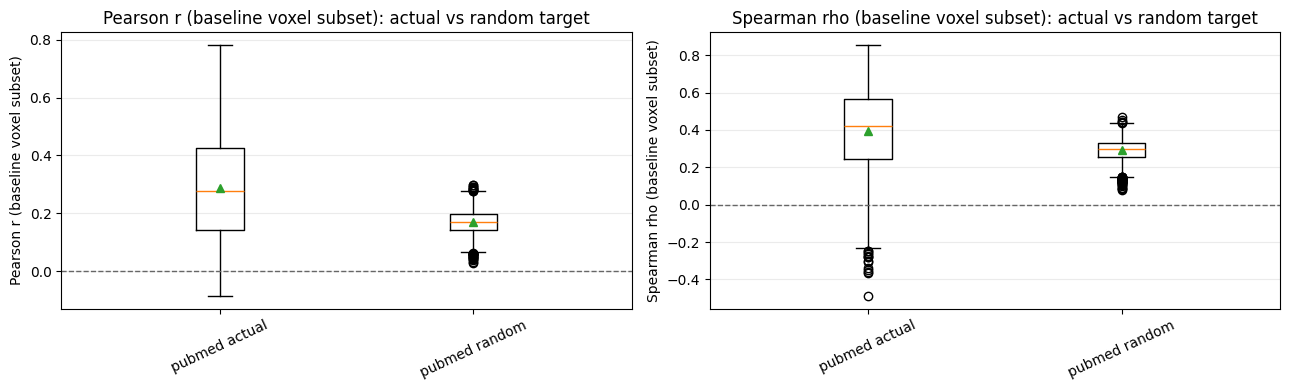

In [12]:
from neurovlm.metrics.text_to_brain import finite_box_values

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax, metric, random_col, title in [
    (axes[0], "pearson_baseline_actual", "pearson_random_mean", "Pearson r (baseline voxel subset)"),
    (axes[1], "spearman_baseline_actual", "spearman_random_mean", "Spearman rho (baseline voxel subset)"),
]:
    data = []
    labels = []
    positions = []
    pos = 1
    for dataset, sub in t2b_all.groupby("dataset"):
        data.extend([finite_box_values(sub[metric]), finite_box_values(sub[random_col])])
        labels.extend([f"{dataset} actual", f"{dataset} random"])
        positions.extend([pos, pos + 0.8])
        pos += 2.2
    ax.boxplot(data, positions=positions, labels=labels, showmeans=True)
    ax.axhline(0, color="0.4", linestyle="--", linewidth=1)
    ax.set_title(f"{title}: actual vs random target")
    ax.set_ylabel(title)
    ax.grid(axis="y", alpha=0.25)
    ax.tick_params(axis="x", rotation=25)
fig.tight_layout()
plt.savefig(OUTPUT_DIR / "t2b_correlation_random_baseline.png", dpi=150, bbox_inches="tight")
plt.show()


## Dice Threshold Sensitivity

This recomputes Dice and spin significance across several percentile thresholds. Stable conclusions across thresholds are stronger than a result that only appears at one arbitrary cutoff. PubMed rows failing the cortical surface-eligibility check remain excluded at every threshold.


In [13]:
from neurovlm.metrics.text_to_brain import sensitivity_rows_for_df

sensitivity_records = []
for dataset, sub in t2b_all.groupby("dataset"):
    sensitivity_records.extend(
        sensitivity_rows_for_df(
            sub.reset_index(drop=True),
            dataset,
            pcts=DICE_SENSITIVITY_PCTS,
            spin_test_n_perm=SPIN_TEST_N_PERM,
            spin_test_random_state=SPIN_TEST_RANDOM_STATE,
            spin_fsaverage_density=SPIN_FSAVERAGE_DENSITY,
            spin_use_neuromaps=SPIN_USE_NEUROMAPS,
            spin_require_neuromaps=SPIN_REQUIRE_NEUROMAPS,
            n_jobs=T2B_METRIC_N_JOBS,
        )
    )
t2b_sensitivity_df = pd.DataFrame(sensitivity_records)
display(t2b_sensitivity_df.groupby(["dataset", "pct"]).agg(dice_mean=("dice", "mean"), dice_std=("dice", "std"), sig_rate=("spin_significant", "mean"), n_surface_metric=("dice", "count"), n_total=("sample", "count")).round(3))



pubmed Dice sensitivity (16 processes):   0%|          | 0/2987 [00:00<?, ?it/s]

dice_mean  dice_std  sig_rate  n_surface_metric  n_total
dataset pct                                                           
pubmed  70.0      0.479     0.117     0.305              1354     2987
        75.0      0.432     0.124     0.302              1354     2987
        80.0      0.381     0.129     0.294              1354     2987
        85.0      0.324     0.131     0.284              1354     2987
        90.0      0.259     0.131     0.272              1354     2987
        95.0      0.178     0.128     0.242              1354     2987

## Metric Distribution Plot

Pearson and Spearman are shown as improvement over the random baseline. Values above zero indicate better-than-random target matching. Dice and spin p-value use only surface-eligible rows; missing PubMed values usually indicate mostly subcortical target activation.


/tmp/ipykernel_8425/4030672522.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(groups, labels=labels, showmeans=True)
/tmp/ipykernel_8425/4030672522.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(groups, labels=labels, showmeans=True)
/tmp/ipykernel_8425/4030672522.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(groups, labels=labels, showmeans=True)
/tmp/ipykernel_8425/4030672522.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(groups,

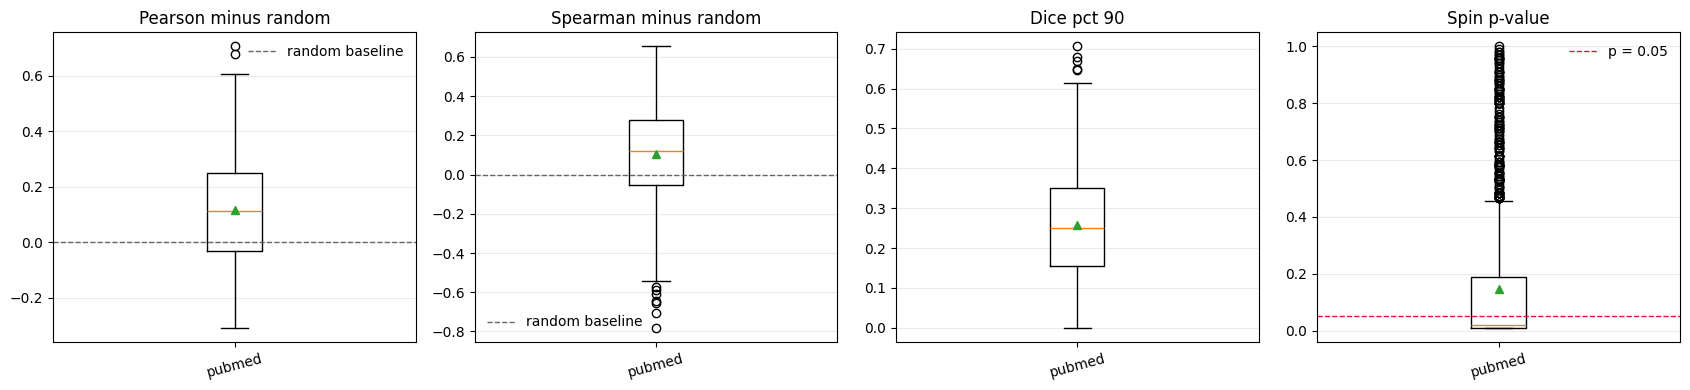

In [14]:
from neurovlm.metrics.text_to_brain import finite_box_values

dice_col = f"dice_pct{DICE_PCT}"
fig, axes = plt.subplots(1, 4, figsize=(17, 4))
plot_df = t2b_all.copy()
for ax, metric, title in zip(axes, ["pearson_minus_random", "spearman_minus_random", dice_col, "spin_p_value"], ["Pearson minus random", "Spearman minus random", f"Dice pct {DICE_PCT}", "Spin p-value"]):
    groups = [finite_box_values(g[metric]) for _, g in plot_df.groupby("dataset")]
    labels = [k for k, _ in plot_df.groupby("dataset")]
    ax.boxplot(groups, labels=labels, showmeans=True)
    if metric in {"pearson_minus_random", "spearman_minus_random"}:
        ax.axhline(0, color="0.4", linestyle="--", linewidth=1, label="random baseline")
        ax.legend(frameon=False)
    if metric == "spin_p_value":
        ax.axhline(0.05, color="crimson", linestyle="--", linewidth=1, label="p = 0.05")
        ax.legend(frameon=False)
    ax.set_title(title)
    ax.grid(axis="y", alpha=0.25)
    ax.tick_params(axis="x", rotation=15)
fig.tight_layout()
plt.savefig(OUTPUT_DIR / "t2b_metric_distributions.png", dpi=150, bbox_inches="tight")
plt.show()


## Dice Threshold Sensitivity Plot

The left panel shows mean Dice as the activation percentile threshold changes; the right panel shows the fraction of samples with spin-test `p < 0.05`. If the conclusion changes sharply across thresholds, the Dice result is threshold-sensitive. Surface-ineligible PubMed rows remain excluded from Dice/spin at all thresholds.


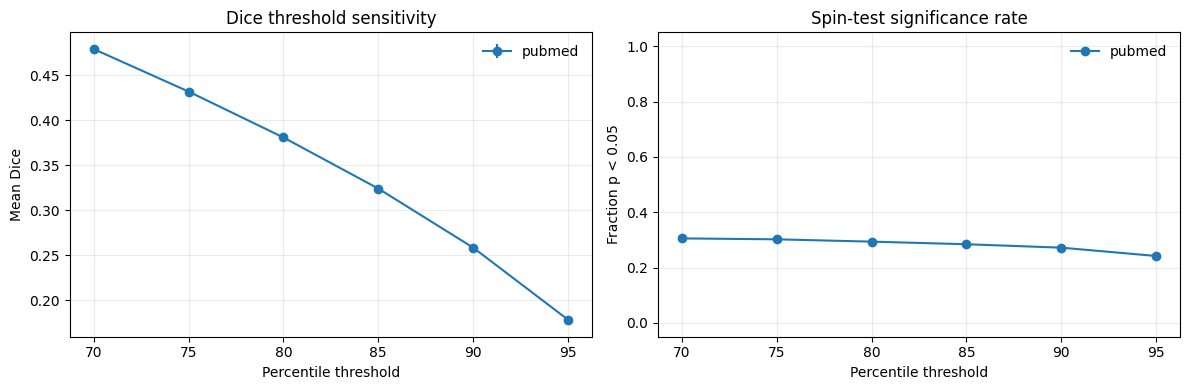

In [15]:
from neurovlm.metrics.text_to_brain import finite_sem

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
summary_plot = t2b_sensitivity_df.groupby(["dataset", "pct"]).agg(
    dice_mean=("dice", "mean"),
    dice_sem=("dice", finite_sem),
    sig_rate=("spin_significant", "mean"),
).reset_index()
for dataset, sub in summary_plot.groupby("dataset"):
    axes[0].errorbar(sub["pct"], sub["dice_mean"], yerr=sub["dice_sem"], marker="o", label=dataset)
    axes[1].plot(sub["pct"], sub["sig_rate"], marker="o", label=dataset)
axes[0].set_xlabel("Percentile threshold")
axes[0].set_ylabel("Mean Dice")
axes[0].set_title("Dice threshold sensitivity")
axes[1].set_xlabel("Percentile threshold")
axes[1].set_ylabel("Fraction p < 0.05")
axes[1].set_ylim(-0.05, 1.05)
axes[1].set_title("Spin-test significance rate")
for ax in axes:
    ax.grid(alpha=0.25)
    ax.legend(frameon=False)
fig.tight_layout()
plt.savefig(OUTPUT_DIR / "t2b_dice_pvalue_sensitivity.png", dpi=150, bbox_inches="tight")
plt.show()


## Dice vs Spin Significance

This scatterplot shows whether larger activation overlap also corresponds to stronger spatial significance. The horizontal line marks `p = 0.05`; points above it are significant after the spin-test null model. Color shows Pearson improvement over random target maps.


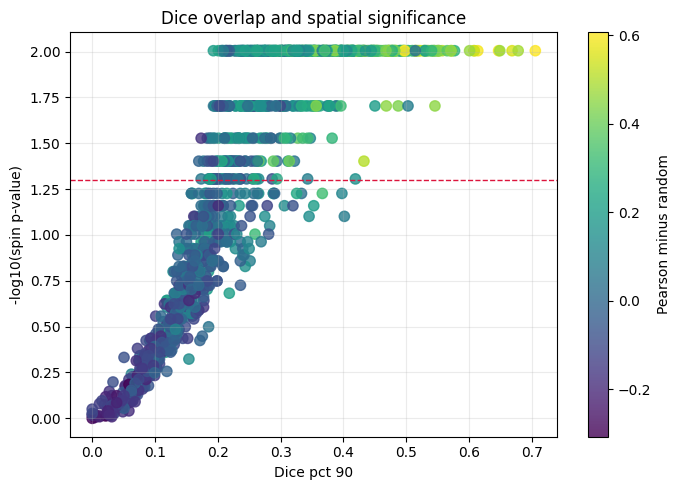

In [16]:
fig, ax = plt.subplots(figsize=(7, 5))
plot_df = t2b_all.dropna(subset=[dice_col, "spin_p_value", "pearson_minus_random"])
if len(plot_df):
    scatter = ax.scatter(plot_df[dice_col], -np.log10(plot_df["spin_p_value"].clip(lower=1e-6)), c=plot_df["pearson_minus_random"], cmap="viridis", s=55, alpha=0.8)
    cb = fig.colorbar(scatter, ax=ax)
    cb.set_label("Pearson minus random")
else:
    ax.text(0.5, 0.5, "No eligible finite Dice/spin rows", ha="center", va="center", transform=ax.transAxes)
ax.axhline(-np.log10(0.05), color="crimson", linestyle="--", linewidth=1)
ax.set_xlabel(f"Dice pct {DICE_PCT}")
ax.set_ylabel("-log10(spin p-value)")
ax.set_title("Dice overlap and spatial significance")
ax.grid(alpha=0.25)
fig.tight_layout()
plt.savefig(OUTPUT_DIR / "t2b_dice_vs_pvalue.png", dpi=150, bbox_inches="tight")
plt.show()


  dataset  generated_image_normalized_k_recall_curve_auc     n
0  pubmed                                       0.817967  2987
contrastive sim: match= 0.27970758080482483 null= 0.10519035160541534 source= {'flatmap_encoder': 2987}
contrastive ranks: median= 286.0 R@1= 0.007030465349849347 R@10= 0.05390023434884499 R@100= 0.2959491128222297
Contrastive: match=0.2797, null=0.1052
Dice pct 70: match=0.4707, null=0.4019
Pearson r: match=0.2870, null=0.1700


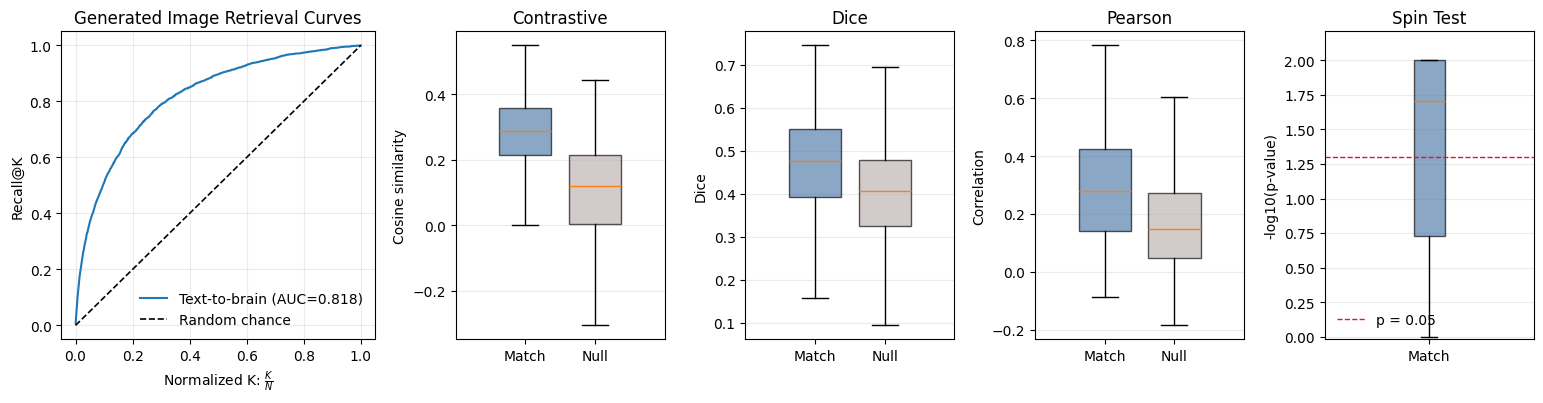

In [ ]:
# Final text-to-brain summary plot: contrastive retrieval, contrastive similarity, Dice, correlation, and spin p-values.
from neurovlm.metrics.text_to_brain import dice_percentile, encode_text_batched, generated_image_text_retrieval_curve

if not {"_brain_pred", "_brain_true"}.issubset(t2b_all.columns):
    raise RuntimeError("Run the text-to-brain evaluation cells first; this plot needs _brain_pred and _brain_true arrays.")

# Set T2B_PLOT_NEG_LOG10_P = False before this cell to plot raw p-values.
T2B_PLOT_NEG_LOG10_P = bool(globals().get("T2B_PLOT_NEG_LOG10_P", True))

plot_df = t2b_all.copy()
if "dataset" in plot_df.columns and "pubmed" in set(plot_df["dataset"]):
    plot_df = plot_df[plot_df["dataset"] == "pubmed"].copy()
plot_df = plot_df.reset_index(drop=True)

_rng = np.random.default_rng(13)
_corr_max_voxels = globals().get("T2B_RANDOM_BASELINE_SPEARMAN_MAX_VOXELS", 5000)
_contrastive_batch_size = globals().get("T2B_CONTRASTIVE_BATCH_SIZE", 256)
_text_encode_batch_size = globals().get("T2B_TEXT_ENCODE_BATCH_SIZE", 32)
_contrastive_threshold = globals().get("T2B_CONTRASTIVE_MAP_THRESHOLD", None)


def _stack_flatmaps(values):
    return np.stack([np.asarray(v, dtype="float32").ravel() for v in values])


def _zscore_rows(x):
    x = np.asarray(x, dtype="float32")
    x = x - x.mean(axis=1, keepdims=True)
    denom = x.std(axis=1, keepdims=True)
    return x / np.clip(denom, 1e-6, None)


def _rank_zscore_rows(x):
    x = np.asarray(x, dtype="float32")
    try:
        ranks = rankdata(x, method="average", axis=1).astype("float32")
    except TypeError:
        ranks = np.vstack([rankdata(row, method="average") for row in x]).astype("float32")
    return _zscore_rows(ranks)


def _deranged_indices(n, rng):
    if n < 2:
        return np.arange(n)
    perm = rng.permutation(n)
    fixed = np.flatnonzero(perm == np.arange(n))
    if len(fixed) > 1:
        perm[fixed] = np.roll(perm[fixed], 1)
    elif len(fixed) == 1:
        i = fixed[0]
        j = (i + 1) % n
        perm[i], perm[j] = perm[j], perm[i]
    return perm


def _match_null_correlation(pred_maps, true_maps, *, max_voxels=5000, seed=13):
    n, d = pred_maps.shape
    if max_voxels is not None and max_voxels < d:
        vox = np.random.default_rng(seed).choice(d, size=int(max_voxels), replace=False)
        pred_maps = pred_maps[:, vox]
        true_maps = true_maps[:, vox]
    null_idx = _deranged_indices(n, np.random.default_rng(seed))
    denom = float(pred_maps.shape[1])

    pred_z = _zscore_rows(pred_maps)
    true_z = _zscore_rows(true_maps)
    pearson_match = np.einsum("ij,ij->i", pred_z, true_z) / denom
    pearson_null = np.einsum("ij,ij->i", pred_z, true_z[null_idx]) / denom

    pred_rank_z = _rank_zscore_rows(pred_maps)
    true_rank_z = _rank_zscore_rows(true_maps)
    spearman_match = np.einsum("ij,ij->i", pred_rank_z, true_rank_z) / denom
    spearman_null = np.einsum("ij,ij->i", pred_rank_z, true_rank_z[null_idx]) / denom

    pearson_gap = float(np.nanmean(pearson_match) - np.nanmean(pearson_null))
    spearman_gap = float(np.nanmean(spearman_match) - np.nanmean(spearman_null))
    if spearman_gap > pearson_gap:
        return "Spearman rho", spearman_match, spearman_null, spearman_gap
    return "Pearson r", pearson_match, pearson_null, pearson_gap


def _match_null_box(ax, df, metric, *, ylabel, title):
    groups = [df.loc[df["kind"].eq(kind), metric].dropna().values for kind in ["Match", "Null"]]
    bp = ax.boxplot(groups, positions=[0.4, 0.6], tick_labels=["Match", "Null"], showfliers=False, patch_artist=True)
    for patch, label in zip(bp["boxes"], ["Match", "Null"]):
        patch.set_facecolor("#4C78A8" if label == "Match" else "#BAB0AC")
        patch.set_alpha(0.65)
    ax.set_title(title)
    ax.set_xlim(0.2, 0.8)
    ax.set_ylabel(ylabel)
    ax.grid(axis="y", alpha=0.25)
    return groups


def _pvalue_transform(values):
    values = np.asarray(values, dtype=float)
    values = values[np.isfinite(values)]
    if T2B_PLOT_NEG_LOG10_P:
        return -np.log10(np.clip(values, 1e-300, None))
    return values


# 1. Generated image retrieval curves in NeuroVLM image-vs-text contrastive space.
curve_records = []
auc_records = []
rank_records = []
for dataset, sub in plot_df.groupby("dataset", sort=False):
    pred_maps = _stack_flatmaps(sub["_brain_pred"])
    texts = sub["_text_input_full"].astype(str).tolist() if "_text_input_full" in sub.columns else sub["text_input"].astype(str).tolist()
    _text_fingerprint = int(pd.util.hash_pandas_object(pd.Series(texts), index=False).sum())
    _text_cache_key = f"_t2b_text_latents_{dataset}_{len(texts)}_{_text_fingerprint}"
    text_latents = globals().get(_text_cache_key)
    if text_latents is None:
        text_latents = encode_text_batched(nvlm, texts, batch_size=_text_encode_batch_size)
        globals()[_text_cache_key] = text_latents
    auc, curve, ranks = generated_image_text_retrieval_curve(
        nvlm,
        pred_maps,
        texts,
        text_latents=text_latents,
        image_batch_size=_contrastive_batch_size,
        text_encode_batch_size=_text_encode_batch_size,
        threshold=_contrastive_threshold,
        seed=13,
    )
    ranks["contrastive_source"] = "flatmap_encoder"
    curve["dataset"] = dataset
    ranks["dataset"] = dataset
    curve_records.append(curve)
    rank_records.append(ranks)
    auc_records.append({"dataset": dataset, "generated_image_normalized_k_recall_curve_auc": auc, "n": len(sub)})

t2b_recall_curve_df = pd.concat(curve_records, ignore_index=True) if curve_records else pd.DataFrame()
t2b_recall_auc_df = pd.DataFrame(auc_records)
t2b_contrastive_rank_df = pd.concat(rank_records, ignore_index=True) if rank_records else pd.DataFrame()

contrastive_records = []
for _, row in t2b_contrastive_rank_df.iterrows():
    contrastive_records.append({"dataset": row["dataset"], "kind": "Match", "contrastive_sim": row["matched_contrastive_sim"]})
    contrastive_records.append({"dataset": row["dataset"], "kind": "Null", "contrastive_sim": row["null_contrastive_sim"]})
t2b_contrastive_plot_df = pd.DataFrame(contrastive_records)

# 2. Dice: use the threshold with the highest mean Dice from the sensitivity table when available.
if "t2b_sensitivity_df" in globals() and len(t2b_sensitivity_df):
    _dice_by_pct = t2b_sensitivity_df.groupby("pct")["dice"].mean().dropna()
    best_dice_pct = float(_dice_by_pct.idxmax()) if len(_dice_by_pct) else float(DICE_PCT)
else:
    best_dice_pct = float(DICE_PCT)

dice_records = []
for dataset, sub in plot_df.groupby("dataset", sort=False):
    true_maps = _stack_flatmaps(sub["_brain_true"])
    null_pos = _deranged_indices(len(sub), _rng)
    for row_pos, (_, row) in enumerate(sub.iterrows()):
        pred = np.asarray(row["_brain_pred"], dtype="float32").ravel()
        dice_records.append({
            "dataset": dataset,
            "kind": "Match",
            "dice": dice_percentile(pred, np.asarray(row["_brain_true"], dtype="float32").ravel(), pct=best_dice_pct),
        })
        dice_records.append({
            "dataset": dataset,
            "kind": "Null",
            "dice": dice_percentile(pred, true_maps[null_pos[row_pos]], pct=best_dice_pct),
        })

t2b_dice_plot_df = pd.DataFrame(dice_records)

# 3. Pearson or Spearman, whichever has the larger match-null gap.
corr_records = []
corr_title_by_dataset = {}
for dataset, sub in plot_df.groupby("dataset", sort=False):
    pred_maps = _stack_flatmaps(sub["_brain_pred"])
    true_maps = _stack_flatmaps(sub["_brain_true"])
    corr_title, corr_match, corr_null, corr_gap = _match_null_correlation(
        pred_maps,
        true_maps,
        max_voxels=_corr_max_voxels,
        seed=13,
    )
    corr_title_by_dataset[dataset] = corr_title
    corr_records.extend({"dataset": dataset, "kind": "Match", "correlation": v} for v in corr_match)
    corr_records.extend({"dataset": dataset, "kind": "Null", "correlation": v} for v in corr_null)

t2b_corr_plot_df = pd.DataFrame(corr_records)
corr_title = next(iter(corr_title_by_dataset.values()), "Correlation")
if len(set(corr_title_by_dataset.values())) > 1:
    corr_title = "Best Pearson/Spearman"

fig, axes = plt.subplots(
    1,
    5,
    figsize=(19, 4),
    gridspec_kw={"width_ratios": [3, 2, 2, 2, 2], "wspace": 0.35},
)

ax = axes[0]
for dataset, curve_df in t2b_recall_curve_df.groupby("dataset", sort=False):
    auc_row = t2b_recall_auc_df[t2b_recall_auc_df["dataset"] == dataset]
    auc = float(auc_row["generated_image_normalized_k_recall_curve_auc"].iloc[0]) if len(auc_row) else np.nan
    ax.plot(
        curve_df["normalized_k"],
        curve_df["recall_at_normalized_k"],
        label=f"Text-to-brain (AUC={auc:.3f})",
    )
ax.plot([0, 1], [0, 1], "k--", linewidth=1.2, label="Random chance")
ax.set_ylabel("Recall@K")
ax.set_xlabel(r"Normalized K: $\frac{K}{N}$")
ax.set_title("Generated Image Retrieval Curves")
ax.grid(alpha=0.25)
ax.legend(frameon=False)

k_groups = _match_null_box(axes[1], t2b_contrastive_plot_df, "contrastive_sim", ylabel="Cosine similarity", title="Contrastive")
d_groups = _match_null_box(axes[2], t2b_dice_plot_df, "dice", ylabel="Dice", title="Dice")
c_groups = _match_null_box(axes[3], t2b_corr_plot_df, "correlation", ylabel="Correlation", title="Pearson")

ax = axes[4]
pval_df = plot_df.dropna(subset=["spin_p_value"]) if "spin_p_value" in plot_df.columns else pd.DataFrame()
if len(pval_df):
    p_groups = [_pvalue_transform(g["spin_p_value"].to_numpy()) for _, g in pval_df.groupby("dataset", sort=False)]
    p_labels = [str(k) for k, _ in pval_df.groupby("dataset", sort=False)]
    bp = ax.boxplot(p_groups, tick_labels=["Match"], showfliers=False, patch_artist=True)
    for patch in bp["boxes"]:
        patch.set_facecolor("#4C78A8")
        patch.set_alpha(0.65)
    thresh = -np.log10(0.05) if T2B_PLOT_NEG_LOG10_P else 0.05
    ax.axhline(thresh, color="crimson", linestyle="--", linewidth=1, label="p = 0.05")
    ax.legend(frameon=False)#, loc="upper right")
    if T2B_PLOT_NEG_LOG10_P:
        ymax = max(thresh * 1.2, max((np.nanmax(g) for g in p_groups if len(g)), default=thresh) * 1.1)
        #ax.set_ylim(0, ymax)
    else:
        ax.set_ylim(0, min(1.0, max(0.1, float(pval_df["spin_p_value"].max()) * 1.1)))
else:
    ax.text(0.5, 0.5, "No finite spin-test p-values\nSPIN_USE_NEUROMAPS=False", ha="center", va="center", transform=ax.transAxes)
    ax.set_xticks([])
    ax.set_ylim(0, 1)
ax.set_title("Spin Test")
ax.set_ylabel("-log10(p-value)" if T2B_PLOT_NEG_LOG10_P else "p-value")
ax.set_ylim(-0.02 , 2.21,)
ax.grid(axis="y", alpha=0.25)

print(t2b_recall_auc_df)
if len(t2b_contrastive_rank_df):
    print(
        "contrastive sim:",
        "match=", float(t2b_contrastive_rank_df["matched_contrastive_sim"].mean()),
        "null=", float(t2b_contrastive_rank_df["null_contrastive_sim"].mean()),
        "source=", t2b_contrastive_rank_df.get("contrastive_source", pd.Series(["flatmap_encoder"])).value_counts().to_dict(),
    )
    print(
        "contrastive ranks:",
        "median=", float(t2b_contrastive_rank_df["rank"].median()),
        "R@1=", float((t2b_contrastive_rank_df["rank"] <= 1).mean()),
        "R@10=", float((t2b_contrastive_rank_df["rank"] <= 10).mean()),
        "R@100=", float((t2b_contrastive_rank_df["rank"] <= 100).mean()),
    )
print(f"Contrastive: match={np.nanmean(k_groups[0]):.4f}, null={np.nanmean(k_groups[1]):.4f}")
print(f"Dice pct {best_dice_pct:g}: match={np.nanmean(d_groups[0]):.4f}, null={np.nanmean(d_groups[1]):.4f}")
print(f"{corr_title}: match={np.nanmean(c_groups[0]):.4f}, null={np.nanmean(c_groups[1]):.4f}")

plt.savefig(OUTPUT_DIR / "text_to_brain_metrics_pubmed.svg")#, bbox_inches="tight")
plt.show()



In [34]:
import numpy as np
import pandas as pd
import mpmath as mp

mp.mp.dps = 100


def welch_ttest_with_mp_p(x, y, digits=3):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    x = x[np.isfinite(x)]
    y = y[np.isfinite(y)]

    nx, ny = len(x), len(y)
    if nx < 2 or ny < 2:
        return np.nan, np.nan, np.nan, np.nan

    mx, my = x.mean(), y.mean()
    vx, vy = x.var(ddof=1), y.var(ddof=1)

    se2 = vx / nx + vy / ny
    t = (mx - my) / np.sqrt(se2)
    df = se2**2 / ((vx / nx)**2 / (nx - 1) + (vy / ny)**2 / (ny - 1))

    # Two-sided Student t p-value:
    # p = I_{df / (df + t^2)}(df / 2, 1 / 2)
    df_mp = mp.mpf(str(df))
    t_mp = mp.mpf(str(abs(t)))
    x_mp = df_mp / (df_mp + t_mp**2)
    p_mp = mp.betainc(df_mp / 2, mp.mpf("0.5"), 0, x_mp, regularized=True)

    log10_p = mp.log10(p_mp)
    exponent = mp.floor(log10_p)
    mantissa = mp.power(10, log10_p - exponent)
    p_sci = f"{float(mantissa):.{digits}f}e{int(exponent)}"

    return float(t), float(df), float(log10_p), p_sci


_required = ["t2b_contrastive_plot_df", "t2b_dice_plot_df", "t2b_corr_plot_df"]
_missing = [name for name in _required if name not in globals()]
if _missing:
    raise RuntimeError(f"Run the final text-to-brain summary plot cell first; missing: {_missing}")

metric_specs = [
    ("contrastive_sim", "Contrastive cosine", t2b_contrastive_plot_df, "higher_is_better"),
    ("dice", f"Dice pct {best_dice_pct:g}" if "best_dice_pct" in globals() else "Dice", t2b_dice_plot_df, "higher_is_better"),
    ("correlation", "Pearson/Spearman correlation", t2b_corr_plot_df, "higher_is_better"),
]

rows = []
for metric, label, df_metric, direction in metric_specs:
    if metric not in df_metric.columns or "kind" not in df_metric.columns:
        continue

    matched = df_metric.loc[df_metric["kind"].eq("Match"), metric].dropna().to_numpy()
    null = df_metric.loc[df_metric["kind"].eq("Null"), metric].dropna().to_numpy()
    t_stat, df, log10_p, p_sci = welch_ttest_with_mp_p(matched, null)

    rows.append({
        "metric": metric,
        "label": label,
        "direction": direction,
        "n_matched": len(matched),
        "n_null": len(null),
        "matched_mean": matched.mean() if len(matched) else np.nan,
        "null_mean": null.mean() if len(null) else np.nan,
        "mean_diff": matched.mean() - null.mean() if len(matched) and len(null) else np.nan,
        "matched_std": matched.std(ddof=1) if len(matched) > 1 else np.nan,
        "null_std": null.std(ddof=1) if len(null) > 1 else np.nan,
        "t": t_stat,
        "df": df,
        "log10_p": log10_p,
        "p_sci": p_sci,
    })

t2b_match_null_ttest_df = pd.DataFrame(rows)
t2b_match_null_ttest_df


,metric,label,direction,n_matched,n_null,matched_mean,null_mean,mean_diff,matched_std,null_std,t,df,log10_p,p_sci
0,contrastive_sim,Contrastive cosine,higher_is_better,2987,2987,0.279708,0.105190,0.174517,0.113136,0.144385,51.997715,5648.862307,-481.492747,3.216e-482
1,dice,Dice pct 70,higher_is_better,2987,2987,0.470668,0.401891,0.068777,0.110504,0.110392,24.065331,5971.993847,-121.488630,3.246e-122
2,correlation,Pearson/Spearman correlation,higher_is_better,2987,2987,0.286999,0.170021,0.116978,0.181757,0.156462,26.657950,5842.725325,-147.127552,7.455e-148
